In [1]:
import cloudpickle

results_pikl = "pikls/20260115_133527/all_datasets_full.pkl"
#TChiWZ_17_pikl = "pikls/20251219_142853/TChiWZ2017UL.pkl"

with open(results_pikl, "rb") as f:
    json = cloudpickle.load(f)
    results = json["results"]

In [2]:
results.keys()

dict_keys(['WtoLNu_2Jets_2023', 'TChiWZ_2018UL', 'TChiWZ_2017UL', 'TTto2L2Nu_2017UL', 'WWTo2L2Nu_2017UL', 'TTtoLNu_2023'])

```
Hist(
  Variable([2, 3, 4, 5, 7, 10, 20, 45, 75, 1000], name='pt', label='Electron $p_T$ (GeV)'),
  Regular(500, 0, 500, name='pt_long', label='Electron $p_T$ (GeV)'),
  Variable([0, 0.8, 1.4442, 1.556, 2.5], name='eta', label='Electron $\\eta$'),
  IntCategory([-10, 1, 10, 100, 1000], name='gen', label='Electron Gen Tag'),
  IntCategory([-1, 1, 10, 100], name='qual', label='Electron Quality Tag'),
  storage=Double()) # Sum: 6794781.0 (8539294.0 with flow)
```

In [3]:
from plotting.pt_eta_eff import plot_eta_pt_eff
from plotting.pt_eff_gsb import make_AN_1d_pt_eff

In [4]:
import matplotlib.pyplot as plt
import mplhep

In [5]:
sample_display_names = {
    'WtoLNu_2Jets_2023': r'$W \to \ell\nu$ + 2Jets (2023)',
    'TChiWZ_2018UL': 'TChiWZ 2018 UL',
    'TChiWZ_2017UL': 'TChiWZ 2017 UL',
    'TTto2L2Nu_2017UL': r'$t\bar{t} \to 2\ell 2\nu$ (2017 UL)',
    'WWTo2L2Nu_2017UL': r'$WW \to 2\ell 2\nu$ (2017 UL)',
    'TTtoLNu_2023': r'$t\bar{t} \to \ell\nu$ (2023)'
}

sample_file_names = {
    'WtoLNu_2Jets_2023': 'Wjets_2023',
    'TChiWZ_2018UL': 'TChiWZ_2018UL',
    'TChiWZ_2017UL': 'TChiWZ_2017UL',
    'TTto2L2Nu_2017UL': 'TTbar_2L2Nu_2017UL',
    'WWTo2L2Nu_2017UL': 'WW_2L2Nu_2017UL',
    'TTtoLNu_2023': 'TTbar_LNu_2023'
}

In [6]:
for key in list(results.keys()):
    print(key)
    break
    
    ele_hist   = results[key]['ele_hist']
    muon_hists = results[key]['muon_hist']
    
    hists = [(ele_hist, "ele"), (muon_hists, "muon")]
    
    quals = [(1j, "bronze"), (10j, "silver"), (100j, "gold")]
    gens = [(1j, "prompt"), (10j, "light fake"), (100j, "heavy fake"),  (1000j, "tau fake")]
    
    # Get custom sample name, fallback to first 20 chars if not in map
    sample_name = sample_display_names.get(key, key[:20])
    file_name = sample_file_names.get(key, key[:20])
    
    for hist in hists:
        for gen in gens:
            
            for qual in quals:
                
                if qual == -1: #this corresponds to leptons that fail baseline+ selection, skip them because we're not interested in them (or comment this out if you are interested in them)
                    continue  
                
                # Numerator: specific gen and qual
                numerator = hist[0].integrate("pt_long")[:, :, gen[0], qual[0]]
                
                # Denominator: specific gen, integrate over qual
                denominator = hist[0].integrate("pt_long").integrate("qual", [q[0] for q in quals])[:, :, gen[0]]

                my_vmax = 1
                
                if ("fake" in gen[1]) and ("bronze" not in qual[1]):
                    my_vmax = 0.45
                
                if plot_eta_pt_eff:
                    plot_eta_pt_eff(
                        numerator, 
                        denominator,
                        "",
                        sample_name=f"{sample_name} {hist[1]} (gen={gen[1]}, qual={qual[1]})",
                        save_name=f"{file_name}_{hist[1]}_{gen[1]}_{qual[1]}",
                        color='plasma',
                        save_fig=True,
                        plot_directory=f"{hist[1]}_2d",
                        vmin=0,
                        vmax=my_vmax,
                        event_count=None,
                        com=13 
                    )

WtoLNu_2Jets_2023


/home/cms-jovyan/dwg_framework/src/plotting/pt_eff_gsb.py:153: RuntimeWarning: invalid value encountered in divide
  eff = num/denom
/home/cms-jovyan/dwg_framework/src/plotting/pt_eff_gsb.py:153: RuntimeWarning: invalid value encountered in divide
  eff = num/denom
/home/cms-jovyan/dwg_framework/src/plotting/pt_eff_gsb.py:153: RuntimeWarning: invalid value encountered in divide
  eff = num/denom
/home/cms-jovyan/dwg_framework/src/plotting/pt_eff_gsb.py:153: RuntimeWarning: invalid value encountered in divide
  eff = num/denom


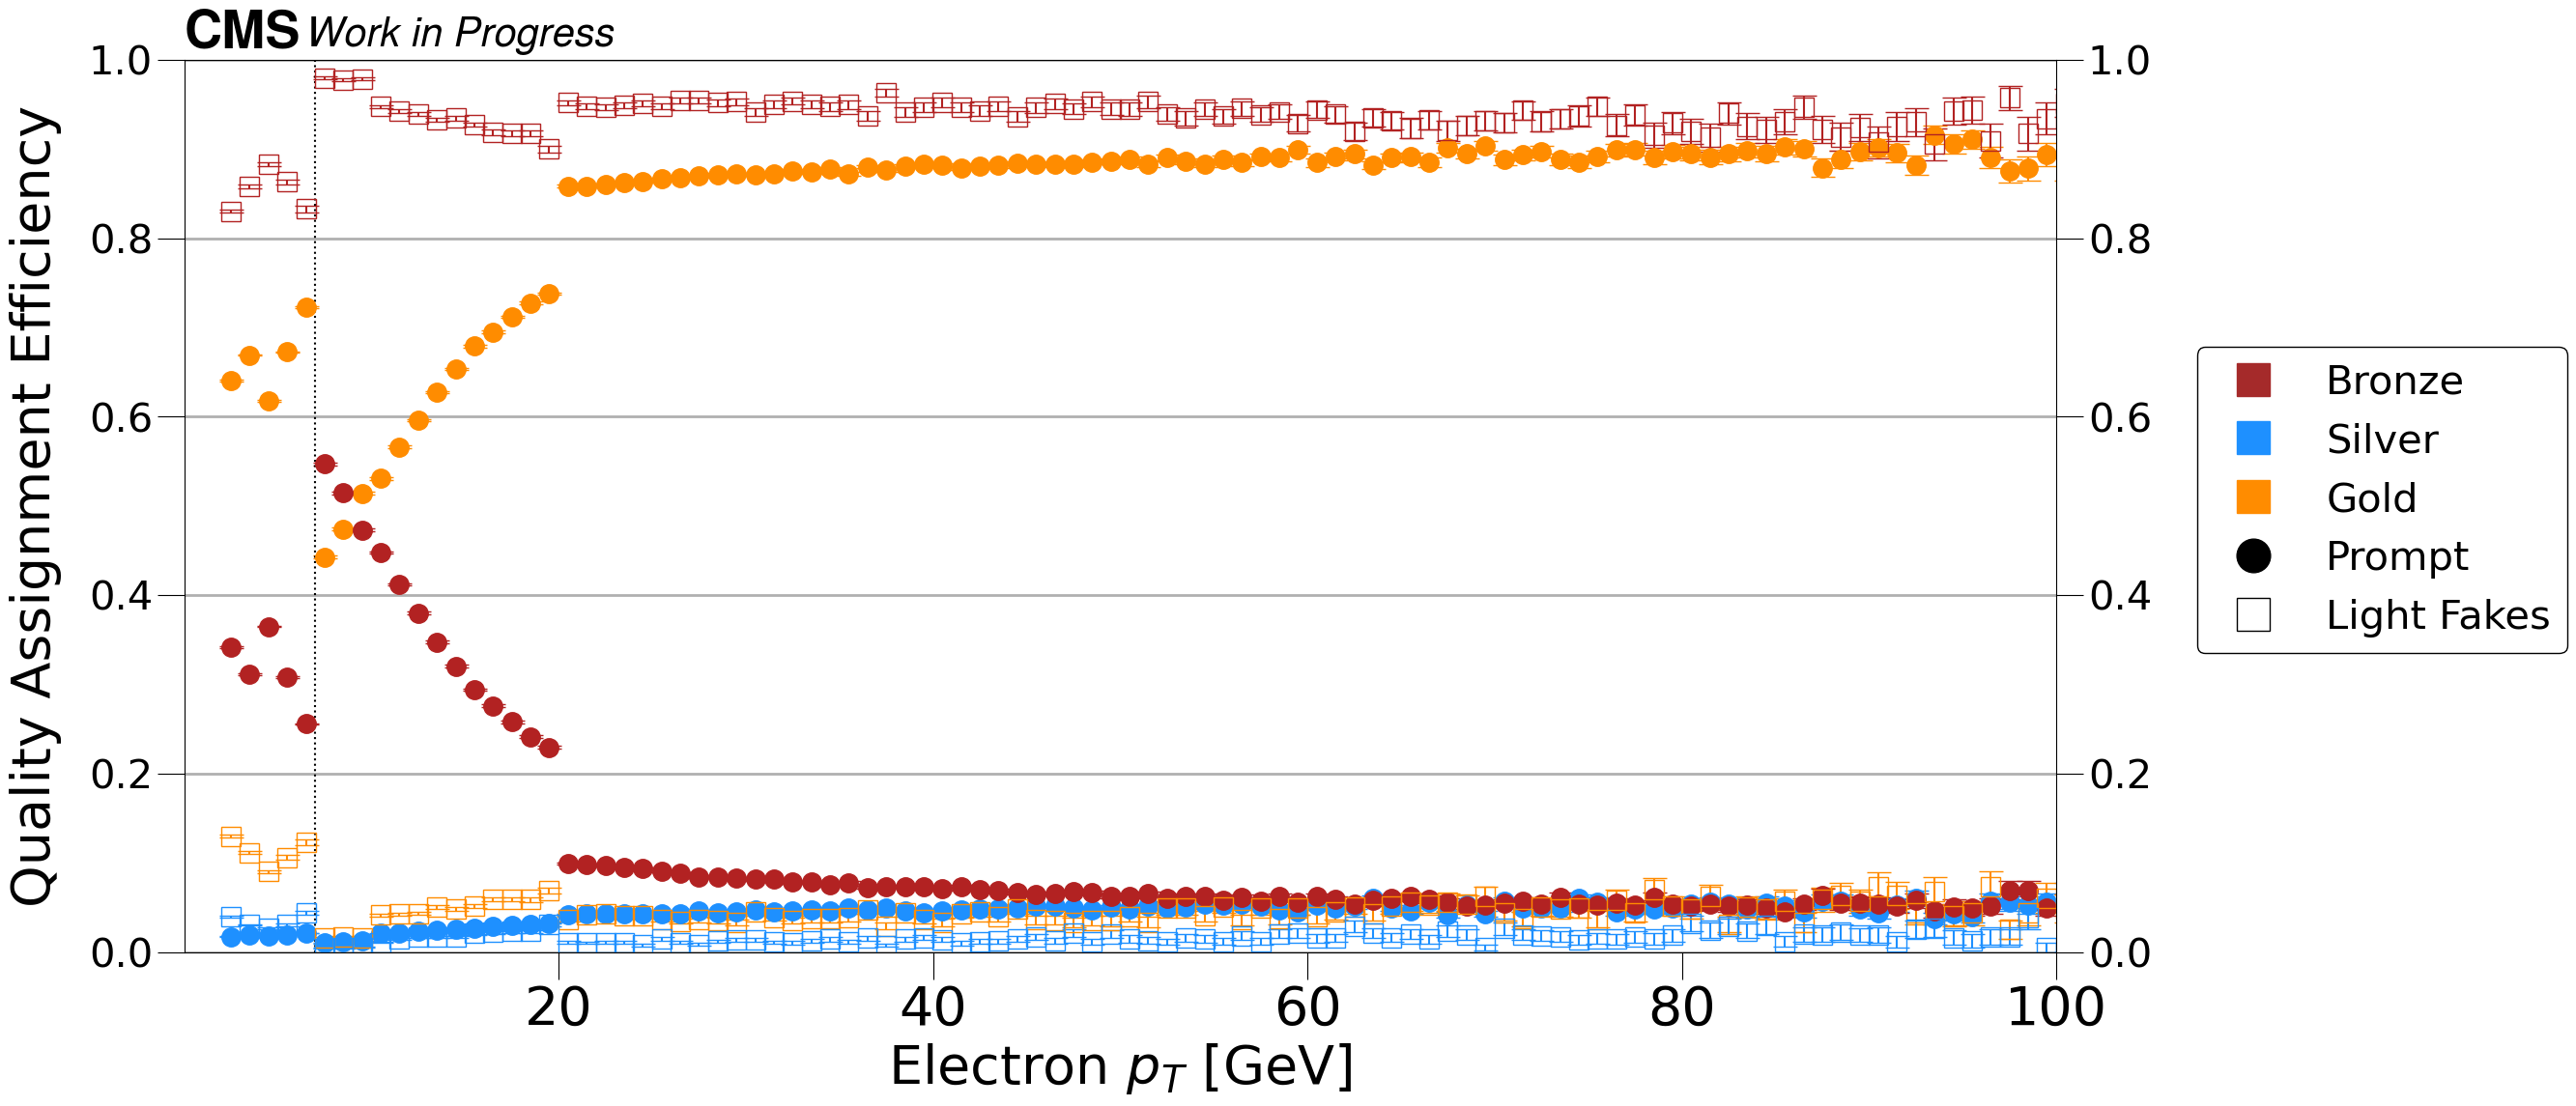

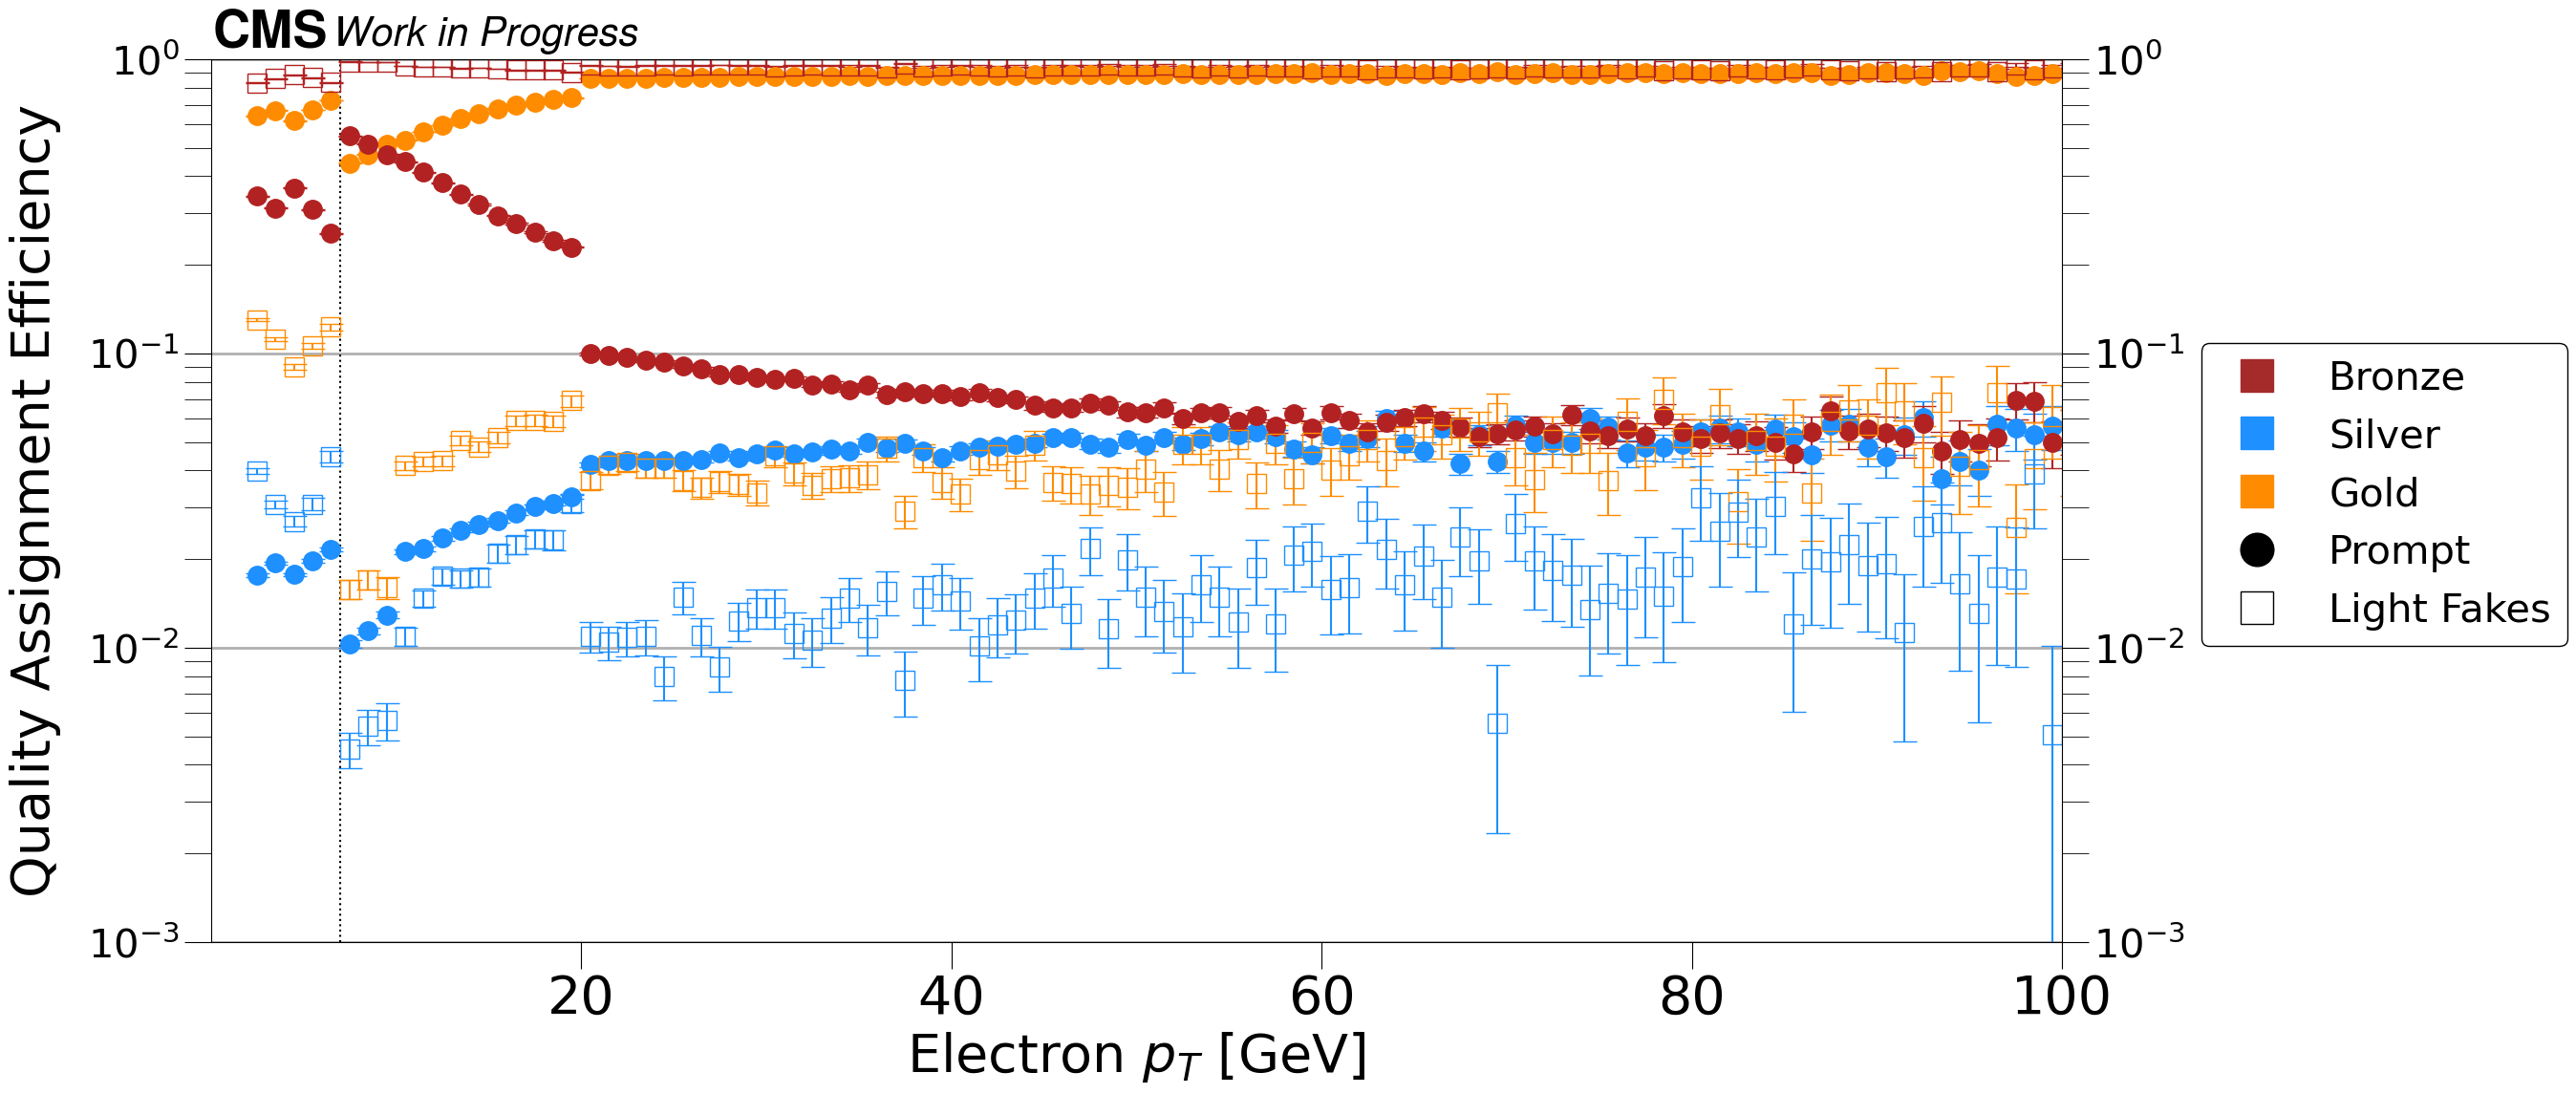

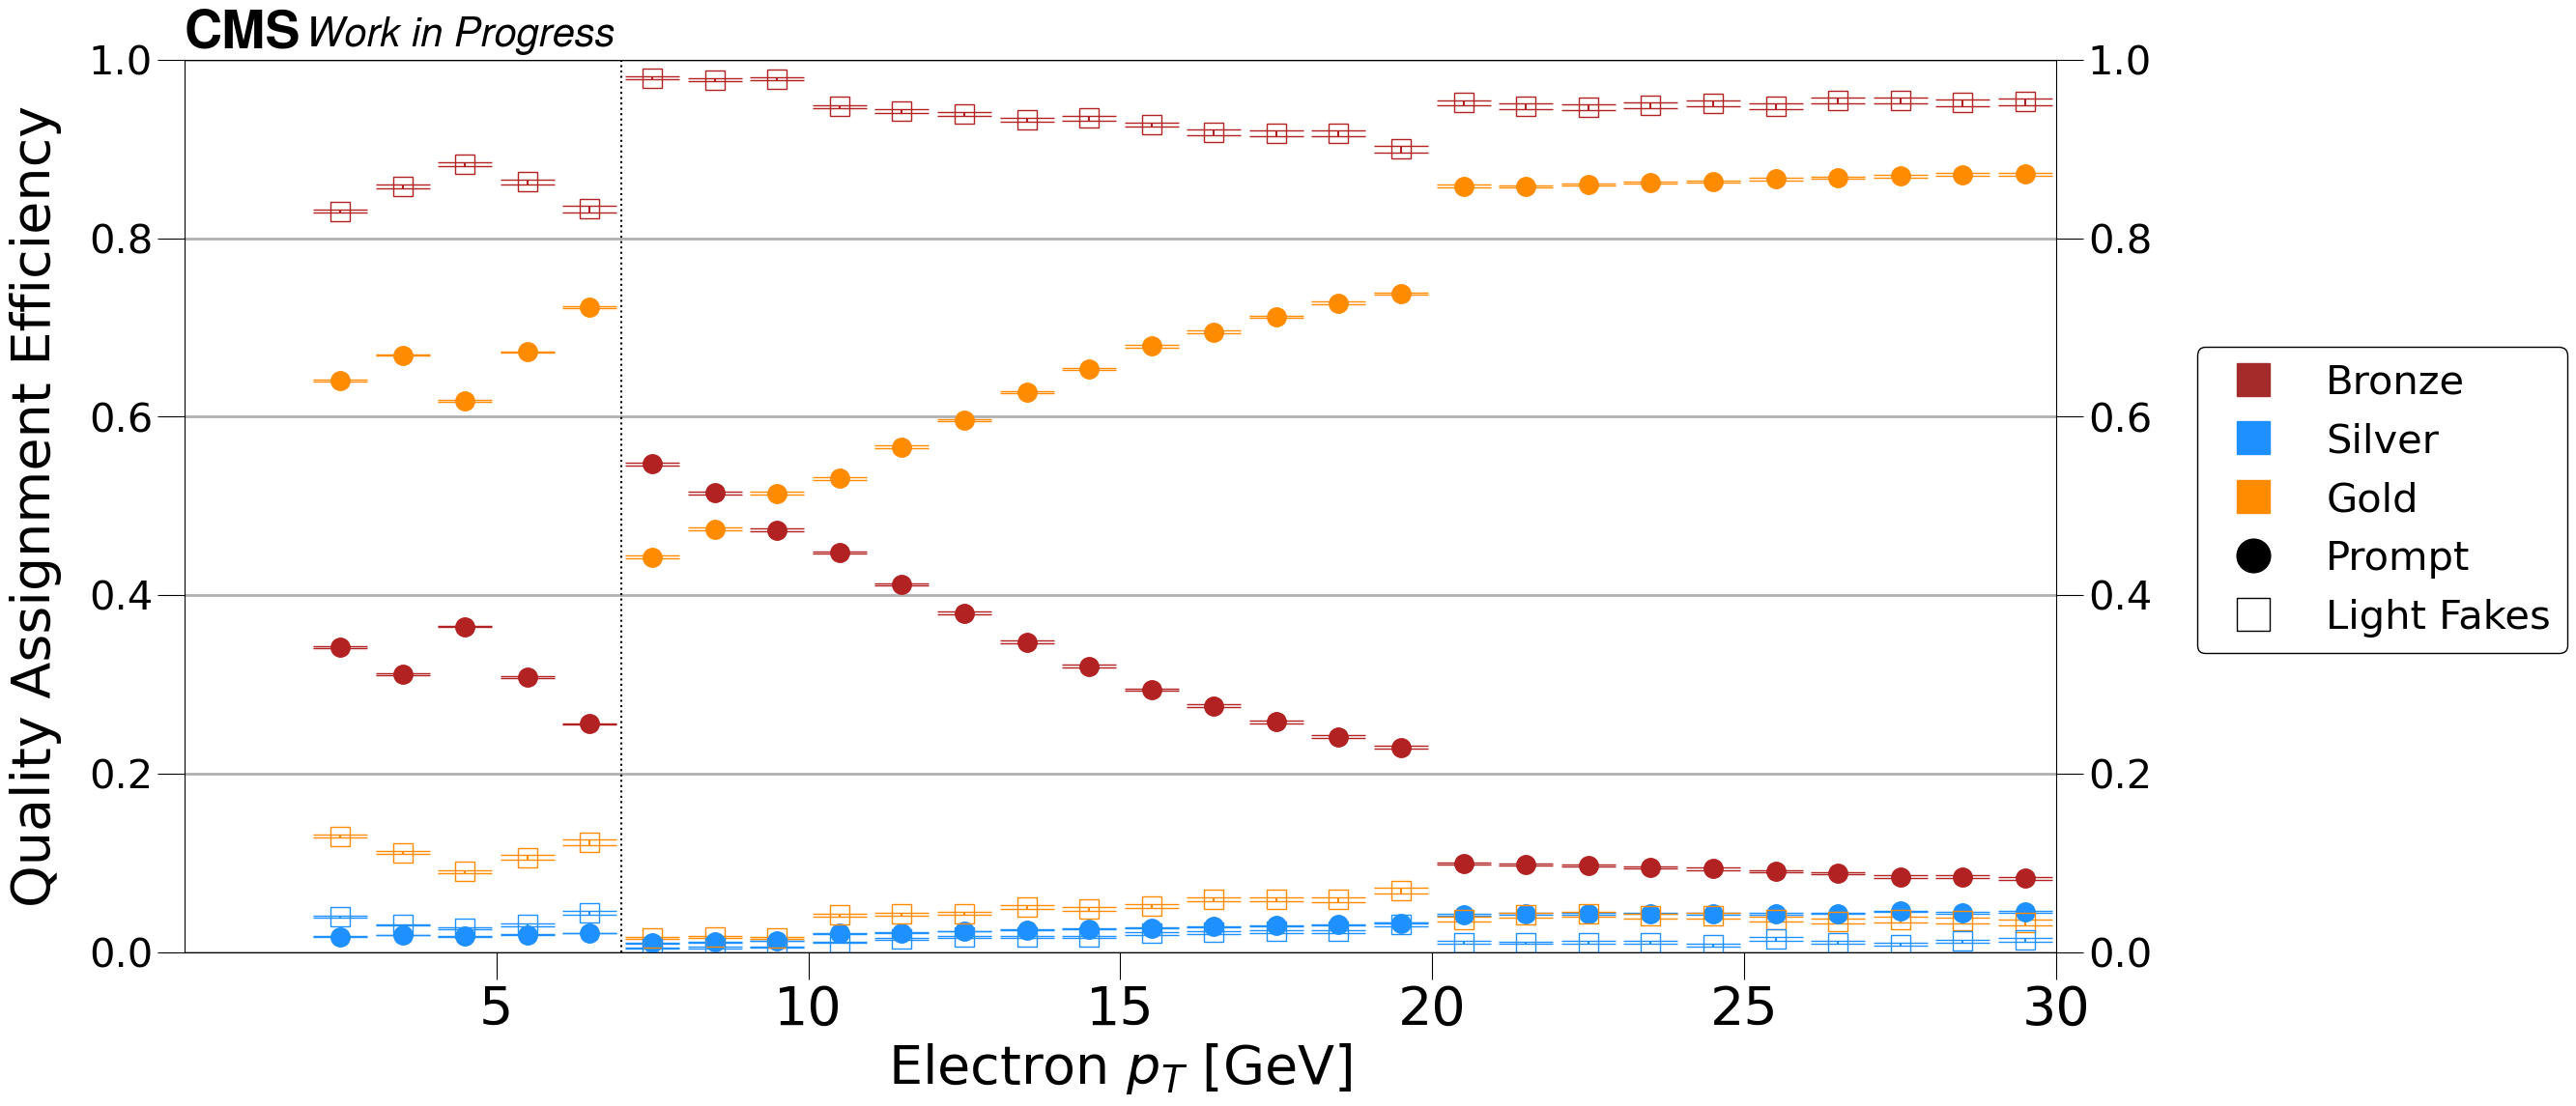

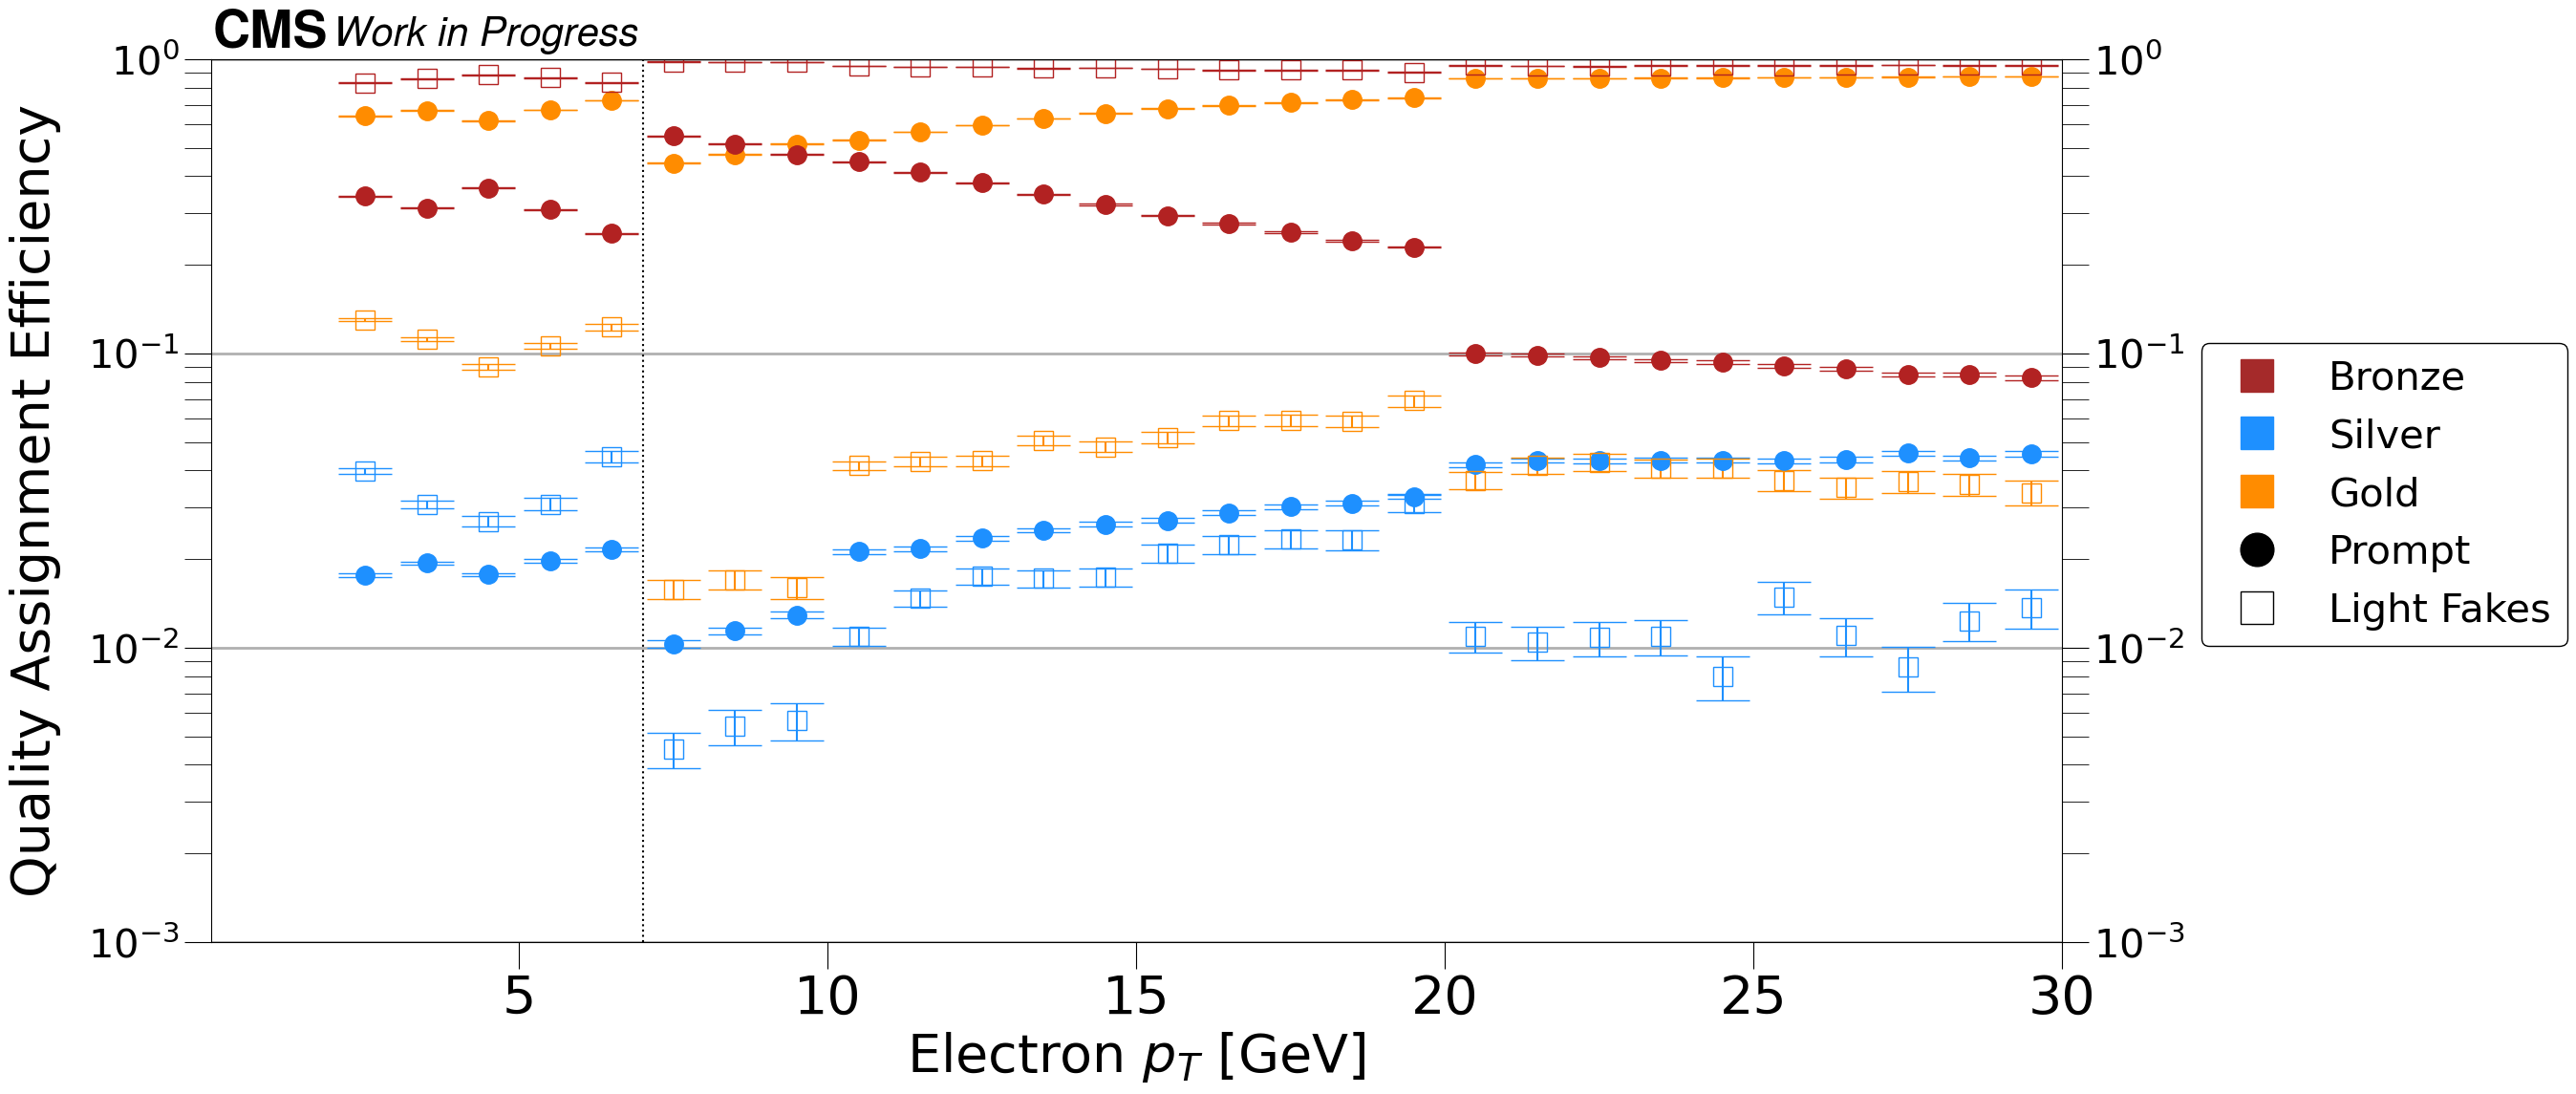

In [7]:

sig_bg_pairs = [
    ("TChiWZ_2017UL","TTto2L2Nu_2017UL")
]

plot_directory = "1D_pt_eff_ele"

for pair in sig_bg_pairs:
    sig_name = pair[0]
    bg_name = pair[1]

    sig_hist = results[sig_name]['ele_hist']
    bg_hist = results[bg_name]['ele_hist']

    make_AN_1d_pt_eff(
        signal=sig_hist[:, :, :, 1j, :],
        fakes=bg_hist[:, :, :, 10j, :],
        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_electron",
        #title=r"TChiWZ Signal vs $t\bar{t}$ Fakes - 2017 UL (Electrons)",
        plot_txt=None,
        savefig=True,
        plot_directory = plot_directory,
        marker_size = 14,
        cap_size = 9,
        lepton_type="Electron",
        com=13,
        fake_label="Light Fakes"
    )
    
    
    make_AN_1d_pt_eff(
        signal=sig_hist[:, :, :, 1j, :],
        fakes=bg_hist[:, :, :, 10j, :],
        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_electron",
        #title=r"TChiWZ Signal vs $t\bar{t}$ Fakes - 2017 UL (Electrons)",
        plot_txt=None,
        savefig=True,
        plot_directory = plot_directory,
        marker_size = 14,
        cap_size = 9,
        lepton_type="Electron",
        com=13,
        log_scale=True,
        fake_label="Light Fakes"
    )

    # 3. Regular log (log scale, up to 30 GeV)
    make_AN_1d_pt_eff(
        signal=sig_hist[:, :, :, 1j, :],
        fakes=bg_hist[:, :, :, 10j, :],
        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_electron",
        #title=r"TChiWZ Signal vs $t\bar{t}$ Fakes - 2017 UL (Electrons)",
        plot_txt=None,
        savefig=True,
        plot_directory = plot_directory,
        marker_size = 14,
        cap_size = 20,
        lepton_type="Electron",
        max_pt=30,
        com=13,
        fake_label="Light Fakes"
    )

    # 4. Regular log (log scale, up to 30 GeV)
    make_AN_1d_pt_eff(
        signal=sig_hist[:, :, :, 1j, :],
        fakes=bg_hist[:, :, :, 10j, :],
        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_electron",
        #title=r"TChiWZ Signal vs $t\bar{t}$ Fakes - 2017 UL (Electrons)",
        plot_txt=None,
        savefig=True,
        plot_directory = plot_directory,
        marker_size = 14,
        cap_size = 20,
        lepton_type="Electron",
        max_pt=30,
        com=13,
        log_scale=True,
        fake_label="Light Fakes"
    )


In [8]:
"""

# ============= ELECTRONS =============
# TChiWZ 2017 signal vs TTbar 2017 fakes (ELECTRONS)
tchiwz_hist = results['TChiWZ_2017UL']['ele_hist']
ttbar_hist = results['TTto2L2Nu_2017UL']['ele_hist']

if make_ele_1d_eff:
    # 1. Regular (linear, up to 100 GeV)
    make_AN_1d_pt_eff(
        signal=tchiwz_hist[:, :, :, 1j, :],
        fakes=ttbar_hist[:, :, :, 10j, :],
        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_electron",
        title=r"TChiWZ Signal vs $t\bar{t}$ Fakes - 2017 UL (Electrons)",
        plot_txt=None,
        savefig=True,
        lepton_type="Electron",
        com=13
    )
    
    # 2. Regular log (log scale, up to 100 GeV)
    make_AN_1d_pt_eff(
        signal=tchiwz_hist[:, :, :, 1j, :],
        fakes=ttbar_hist[:, :, :, 10j, :],
        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_electron",
        title=r"TChiWZ Signal vs $t\bar{t}$ Fakes - 2017 UL (Electrons)",
        plot_txt=None,
        savefig=True,
        lepton_type="Electron",
        com=13,
        log_scale=True
    )
    
    # 3. Regular up to 30 GeV (linear, up to 30 GeV)
    make_AN_1d_pt_eff(
        signal=tchiwz_hist[:, :, :, 1j, :],
        fakes=ttbar_hist[:, :, :, 10j, :],
        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_electron_30GeV",
        title=r"TChiWZ Signal vs $t\bar{t}$ Fakes - 2017 UL (Electrons)",
        plot_txt=None,
        savefig=True,
        lepton_type="Electron",
        com=13,
        max_pt=30
    )
    
    # 4. Log 30 GeV (log scale, up to 30 GeV)
    make_AN_1d_pt_eff(
        signal=tchiwz_hist[:, :, :, 1j, :],
        fakes=ttbar_hist[:, :, :, 10j, :],
        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_electron_30GeV",
        title=r"TChiWZ Signal vs $t\bar{t}$ Fakes - 2017 UL (Electrons)",
        plot_txt=None,
        savefig=True,
        lepton_type="Electron",
        com=13,
        max_pt=30,
        log_scale=True
    )

if make_mu_1d_eff:
    # ============= MUONS =============
    # TChiWZ 2017 signal vs TTbar 2017 fakes (MUONS)
    tchiwz_hist = results['TChiWZ_2017UL']['muon_hist']
    ttbar_hist = results['TTto2L2Nu_2017UL']['muon_hist']
    
    # 1. Regular (linear, up to 100 GeV)
    make_AN_1d_pt_eff(
        signal=tchiwz_hist[:, :, :, 1j, :],
        fakes=ttbar_hist[:, :, :, 10j, :],
        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_muon",
        title=r"TChiWZ Signal vs $t\bar{t}$ Fakes - 2017 UL (Muons)",
        plot_txt=None,
        savefig=True,
        lepton_type="Muon",
        com=13
    )
    
    # 2. Regular log (log scale, up to 100 GeV)
    make_AN_1d_pt_eff(
        signal=tchiwz_hist[:, :, :, 1j, :],
        fakes=ttbar_hist[:, :, :, 10j, :],
        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_muon",
        title=r"TChiWZ Signal vs $t\bar{t}$ Fakes - 2017 UL (Muons)",
        plot_txt=None,
        savefig=True,
        lepton_type="Muon",
        com=13,
        log_scale=True
    )
    
    # 3. Regular up to 30 GeV (linear, up to 30 GeV)
    make_AN_1d_pt_eff(
        signal=tchiwz_hist[:, :, :, 1j, :],
        fakes=ttbar_hist[:, :, :, 10j, :],
        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_muon_30GeV",
        title=r"TChiWZ Signal vs $t\bar{t}$ Fakes - 2017 UL (Muons)",
        plot_txt=None,
        savefig=True,
        lepton_type="Muon",
        com=13,
        max_pt=30
    )
    
    # 4. Log 30 GeV (log scale, up to 30 GeV)
    make_AN_1d_pt_eff(
        signal=tchiwz_hist[:, :, :, 1j, :],
        fakes=ttbar_hist[:, :, :, 10j, :],
        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_muon_30GeV",
        title=r"TChiWZ Signal vs $t\bar{t}$ Fakes - 2017 UL (Muons)",
        plot_txt=None,
        savefig=True,
        lepton_type="Muon",
        com=13,
        max_pt=30,
        log_scale=True
    )

"""

'\n\n# ============= ELECTRONS =============\n# TChiWZ 2017 signal vs TTbar 2017 fakes (ELECTRONS)\ntchiwz_hist = results[\'TChiWZ_2017UL\'][\'ele_hist\']\nttbar_hist = results[\'TTto2L2Nu_2017UL\'][\'ele_hist\']\n\nif make_ele_1d_eff:\n    # 1. Regular (linear, up to 100 GeV)\n    make_AN_1d_pt_eff(\n        signal=tchiwz_hist[:, :, :, 1j, :],\n        fakes=ttbar_hist[:, :, :, 10j, :],\n        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_electron",\n        title=r"TChiWZ Signal vs $t\x08ar{t}$ Fakes - 2017 UL (Electrons)",\n        plot_txt=None,\n        savefig=True,\n        lepton_type="Electron",\n        com=13\n    )\n    \n    # 2. Regular log (log scale, up to 100 GeV)\n    make_AN_1d_pt_eff(\n        signal=tchiwz_hist[:, :, :, 1j, :],\n        fakes=ttbar_hist[:, :, :, 10j, :],\n        name="TChiWZ_signal_vs_TTbar_fakes_2017UL_electron",\n        title=r"TChiWZ Signal vs $t\x08ar{t}$ Fakes - 2017 UL (Electrons)",\n        plot_txt=None,\n        savefig=True,\n        lept